# Análise e Processamento de Dados

### Prof. Otávio Parraga (PUCRS)

## Do dado bruto ao dado pronto para modelagem

Este notebook percorre a fase de **Preparação dos Dados** do **CRISP-DM**. 
É a etapa que costuma consumir a maior parte do tempo de um projeto de mineração de dados, e também a que mais impacta a qualidade da solução final.

### O que vamos fazer
1. Carregar e entender os dados
2. Estatística descritiva e classificação dos atributos
3. Visualização (histograma, boxplot, dispersão, barras)
4. Correlação entre variáveis numéricas
5. Limpeza: valores ausentes, duplicados e outliers
6. Transformação: codificação de categóricas
7. *Feature engineering* (criação de novos atributos)
8. Transformação: normalização e padronização
9.  Exportação do dataset processado

### Ferramentas
Para manter o código **simples e transparente**, usamos apenas
`pandas`, `numpy` e `matplotlib`. Imputação, *z-score*, regra do IQR,
*one-hot encoding* e normalização são implementados "na mão", assim você
enxerga exatamente o que cada técnica faz.

## 1. Carregamento dos dados

No **Google Colab**, primeiro faça o *upload* do arquivo
`tramontina_clientes.csv` usando o botão de upload (ícone de pasta na barra
lateral esquerda → *Upload*). Depois rode a célula abaixo.

O código tenta dois caminhos: primeiro `Dados/tramontina_clientes.csv` (útil
quando você roda localmente) e, se não encontrar, usa
`tramontina_clientes.csv` (caso típico do Colab, onde o arquivo fica na raiz).

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Caminho do arquivo. No Colab, faça o upload e o segundo caminho será usado.
CAMINHO = 'https://raw.githubusercontent.com/Otavio-Parraga/mba_tramontina/main/Dados/tramontina_clientes.csv'

df = pd.read_csv(CAMINHO)
print('Arquivo carregado de:', CAMINHO)
print('Dimensões (linhas, colunas):', df.shape)
df.head()

Arquivo carregado de: https://raw.githubusercontent.com/Otavio-Parraga/mba_tramontina/main/Dados/tramontina_clientes.csv
Dimensões (linhas, colunas): (260, 24)


,ID_Cliente,Regiao,Canal_Venda,Porte_Cliente,Segmento,Tempo_Relacionamento_meses,Recencia_dias,Frequencia_pedidos_ano,Ticket_Medio_R$,N_Categorias_Compradas,...,Atraso_Medio_Pagamento_dias,Comprou_Cutelaria,Comprou_Panelas,Comprou_Utilidades_Cozinha,Comprou_Ferramentas,Comprou_Eletroportateis,Comprou_Moveis,Comprou_Talheres,Comprou_Jardinagem,Churn
0,TRM1000,Nordeste,Varejo Físico,Grande,Doméstico,39,46,32,760.32,2,...,3,0,1,1,0,0,0,0,0,Sim
1,TRM1001,Sudeste,Marketplace,Pequeno,Corporativo,25,45,8,259.22,7,...,6,1,1,1,1,0,1,1,1,Sim
2,TRM1002,Norte,E-commerce,Pequeno,Doméstico,40,12,7,191.00,3,...,2,1,1,0,0,0,0,1,0,Não
3,TRM1003,Nordeste,Varejo Físico,Médio,Profissional/Food Service,69,208,14,511.54,3,...,19,1,0,1,0,0,0,1,0,Sim
4,TRM1004,Sul,Atacado,Pequeno,Corporativo,9,48,8,224.20,6,...,0,1,1,1,1,0,0,1,1,Sim


## 2. Entendimento dos dados e estatística descritiva

Antes de qualquer transformação, precisamos **conhecer** os dados:
quantas linhas e colunas temos, quais os tipos de cada atributo e como os
valores se distribuem.

In [2]:
# Estrutura geral: tipos de dados e contagem de valores não-nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260 entries, 0 to 259
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID_Cliente                   260 non-null    object 
 1   Regiao                       260 non-null    object 
 2   Canal_Venda                  260 non-null    object 
 3   Porte_Cliente                260 non-null    object 
 4   Segmento                     260 non-null    object 
 5   Tempo_Relacionamento_meses   260 non-null    int64  
 6   Recencia_dias                260 non-null    int64  
 7   Frequencia_pedidos_ano       260 non-null    int64  
 8   Ticket_Medio_R$              260 non-null    float64
 9   N_Categorias_Compradas       260 non-null    int64  
 10  Faturamento_Anual_R$         260 non-null    float64
 11  Desconto_Medio_%             252 non-null    float64
 12  Satisfacao_NPS_1a10          248 non-null    float64
 13  Chamados_Suporte_ano

### Os quatro tipos de atributos

Na mineração de dados classificamos cada coluna por seu **tipo de atributo**.
Isso determina quais técnicas podemos aplicar (média só faz sentido em numérico,
*one-hot* só em nominal, etc.).

| Coluna | Tipo | Observação |
|---|---|---|
| `ID_Cliente` | Identificador (meta) | Não é atributo preditivo, apenas identifica a linha |
| `Regiao` | Nominal (categórico) | Sem ordem |
| `Canal_Venda` | Nominal (categórico) | Sem ordem |
| `Segmento` | Nominal (categórico) | Sem ordem |
| `Porte_Cliente` | **Ordinal** | Tem ordem: Pequeno < Médio < Grande |
| `Tempo_Relacionamento_meses` | Numérico discreto | Contagem em meses |
| `Recencia_dias` | Numérico discreto | Dias desde a última compra |
| `Frequencia_pedidos_ano` | Numérico discreto | Pedidos por ano |
| `Ticket_Medio_R$` | Numérico contínuo | Valor em R$ |
| `N_Categorias_Compradas` | Numérico discreto | Contagem |
| `Faturamento_Anual_R$` | Numérico contínuo | Valor em R$ |
| `Desconto_Medio_%` | Numérico contínuo | Percentual (tem ausentes) |
| `Satisfacao_NPS_1a10` | Numérico contínuo | Nota 1 a 10 (tem ausentes) |
| `Chamados_Suporte_ano` | Numérico discreto | Contagem |
| `Atraso_Medio_Pagamento_dias` | Numérico discreto | Dias |
| `Comprou_*` (8 colunas) | **Binário** (0/1) | Flag de compra por categoria |
| `Churn` | **Alvo** (binário, categórico) | "Sim" / "Não", o que queremos prever |

In [3]:
# Estatística descritiva das colunas numéricas
df.describe()

,Tempo_Relacionamento_meses,Recencia_dias,Frequencia_pedidos_ano,Ticket_Medio_R$,N_Categorias_Compradas,Faturamento_Anual_R$,Desconto_Medio_%,Satisfacao_NPS_1a10,Chamados_Suporte_ano,Atraso_Medio_Pagamento_dias,Comprou_Cutelaria,Comprou_Panelas,Comprou_Utilidades_Cozinha,Comprou_Ferramentas,Comprou_Eletroportateis,Comprou_Moveis,Comprou_Talheres,Comprou_Jardinagem
count,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,252.000000,248.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000
mean,35.865385,70.361538,12.430769,438.699000,4.365385,12285.614654,8.796429,7.384677,3.619231,5.742308,0.707692,0.707692,0.784615,0.315385,0.446154,0.334615,0.715385,0.353846
std,20.004854,44.015179,9.479047,340.817469,1.449655,34510.496104,4.298368,1.372875,2.088120,6.110860,0.455700,0.455700,0.411882,0.465565,0.498051,0.472766,0.452101,0.479084
min,1.000000,5.000000,1.000000,115.940000,1.000000,165.110000,0.000000,3.900000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,22.000000,36.750000,6.000000,193.395000,3.000000,1277.502500,5.675000,6.500000,2.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,33.000000,64.000000,9.000000,292.980000,4.000000,3834.305000,8.450000,7.500000,3.000000,4.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,46.250000,94.000000,17.000000,554.390000,5.000000,9826.655000,12.000000,8.225000,5.000000,10.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,107.000000,264.000000,48.000000,1706.550000,8.000000,502693.890000,20.300000,10.000000,12.000000,25.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### Medidas de tendência central e de dispersão

Vamos calcular "na mão" algumas medidas para reforçar as fórmulas vistas em aula,
usando o `Ticket_Medio_R$` como exemplo:

- **Média** = soma dos valores / quantidade
- **Mediana** = valor central quando ordenamos os dados
- **Moda** = valor mais frequente
- **Variância** = média dos desvios quadrados em relação à média
- **Desvio padrão** = raiz quadrada da variância
- **Amplitude (intervalo)** = máximo − mínimo

In [4]:
col = 'Ticket_Medio_R$'
x = df[col]

media    = x.mean()
mediana  = x.median()
moda     = x.mode().iloc[0]
variancia = x.var()           # variância amostral (divide por n-1)
desvio   = x.std()
amplitude = x.max() - x.min()

print(f'Variável analisada: {col}')
print(f'Média      : {media:.2f}')
print(f'Mediana    : {mediana:.2f}')
print(f'Moda       : {moda:.2f}')
print(f'Variância  : {variancia:.2f}')
print(f'Desvio padr: {desvio:.2f}')
print(f'Amplitude  : {amplitude:.2f}')

# Conferindo a média "na mão" com numpy:
print('\nMédia conferida com numpy:', np.sum(x) / len(x))

Variável analisada: Ticket_Medio_R$
Média      : 438.70
Mediana    : 292.98
Moda       : 126.49
Variância  : 116156.55
Desvio padr: 340.82
Amplitude  : 1590.61

Média conferida com numpy: 438.69899999999996


## 3. Visualização dos dados

Gráficos revelam padrões que números isolados escondem: assimetria,
concentração, outliers e relações entre variáveis. Usamos apenas `matplotlib`.

### 3.1 Histograma: distribuição assimétrica

O `Faturamento_Anual_R$` é fortemente **assimétrico à direita** (*right-skewed*):
a maioria dos clientes fatura pouco e poucos faturam muito. Repare como a
**média** é puxada para cima pelos valores extremos, enquanto a **mediana**
representa melhor o cliente "típico".

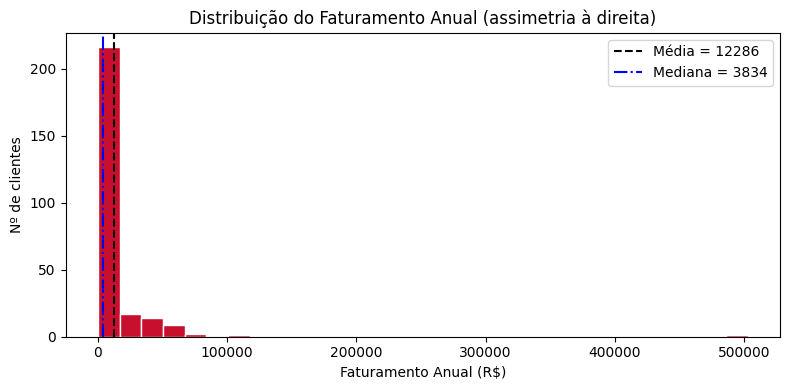

A média (12286) é bem maior que a mediana (3834): sinal de assimetria e de outliers.


In [5]:
col = 'Faturamento_Anual_R$'
plt.figure(figsize=(8, 4))
plt.hist(df[col], bins=30, color='#C8102E', edgecolor='white')
plt.axvline(df[col].mean(),   color='black', linestyle='--', label=f'Média = {df[col].mean():.0f}')
plt.axvline(df[col].median(), color='blue',  linestyle='-.', label=f'Mediana = {df[col].median():.0f}')
plt.title('Distribuição do Faturamento Anual (assimetria à direita)')
plt.xlabel('Faturamento Anual (R$)')
plt.ylabel('Nº de clientes')
plt.legend()
plt.tight_layout()
plt.show()

print('A média (%.0f) é bem maior que a mediana (%.0f): sinal de assimetria e de outliers.'
      % (df[col].mean(), df[col].median()))

### 3.2 Boxplot: visualizando outliers

O boxplot mostra a mediana, os quartis e os pontos fora dos "bigodes"
(candidatos a outliers). Veja como há um cliente muito distante dos demais.

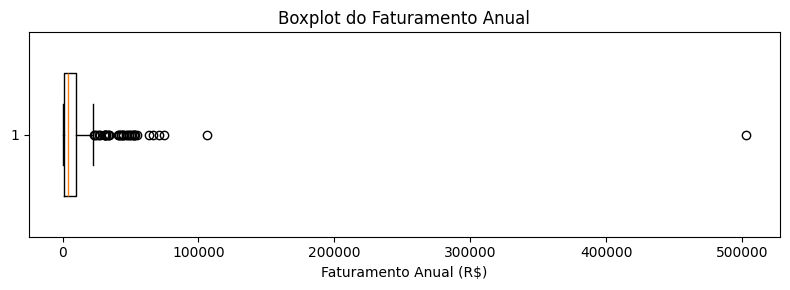

In [6]:
col = 'Faturamento_Anual_R$'
plt.figure(figsize=(8, 3))
plt.boxplot(df[col], vert=False, widths=0.6)
plt.title('Boxplot do Faturamento Anual')
plt.xlabel('Faturamento Anual (R$)')
plt.tight_layout()
plt.show()

### 3.3 Gráfico de dispersão: relação entre dois atributos

A dispersão (*scatter plot*) ajuda a enxergar se duas variáveis numéricas
"andam juntas". Aqui comparamos `Ticket_Medio_R$` e `Faturamento_Anual_R$`,
colorindo por churn.

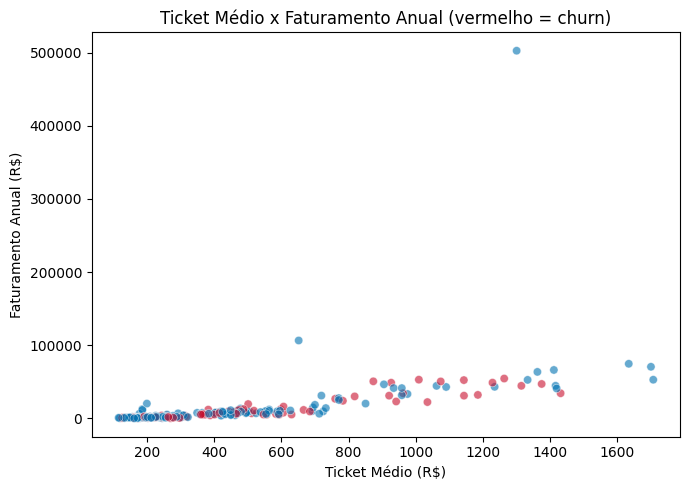

In [7]:
cor_churn = df['Churn'].map({'Sim': '#C8102E', 'Não': '#0072B2'})
plt.figure(figsize=(7, 5))
plt.scatter(df['Ticket_Medio_R$'], df['Faturamento_Anual_R$'],
            c=cor_churn, alpha=0.6, edgecolors='white', linewidths=0.5)
plt.title('Ticket Médio x Faturamento Anual (vermelho = churn)')
plt.xlabel('Ticket Médio (R$)')
plt.ylabel('Faturamento Anual (R$)')
plt.tight_layout()
plt.show()

### 3.4 Gráfico de barras: taxa de churn por canal de venda

Comparar uma métrica de negócio entre categorias é fundamental. Aqui calculamos
a **taxa de churn** (proporção de "Sim") por canal de venda.

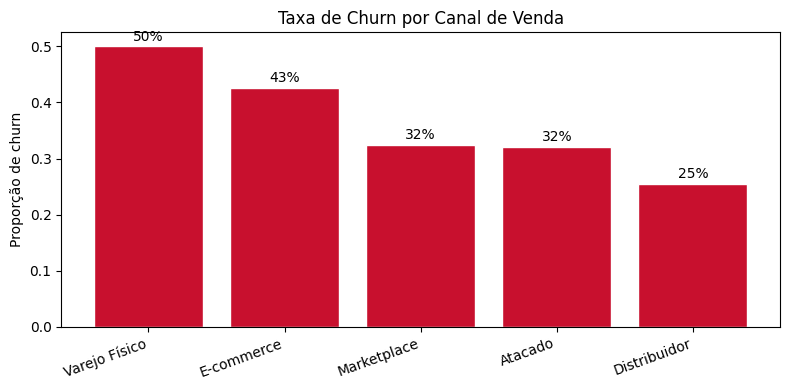

Canal_Venda
Varejo Físico    0.500000
E-commerce       0.426230
Marketplace      0.325000
Atacado          0.321429
Distribuidor     0.254902
Name: Churn, dtype: float64

In [8]:
# Taxa de churn por canal: média de uma flag 0/1 = proporção de churn
churn_bin = (df['Churn'] == 'Sim').astype(int)
taxa = churn_bin.groupby(df['Canal_Venda']).mean().sort_values(ascending=False)

plt.figure(figsize=(8, 4))
plt.bar(taxa.index, taxa.values, color='#C8102E', edgecolor='white')
plt.title('Taxa de Churn por Canal de Venda')
plt.ylabel('Proporção de churn')
plt.xticks(rotation=20, ha='right')
for i, v in enumerate(taxa.values):
    plt.text(i, v + 0.01, f'{v:.0%}', ha='center')
plt.tight_layout()
plt.show()

taxa

## 4. Correlação entre variáveis numéricas

A **correlação de Pearson** mede a força e o sentido da relação **linear**
entre duas variáveis numéricas, variando de −1 (relação inversa perfeita) a
+1 (relação direta perfeita), passando por 0 (sem relação linear).

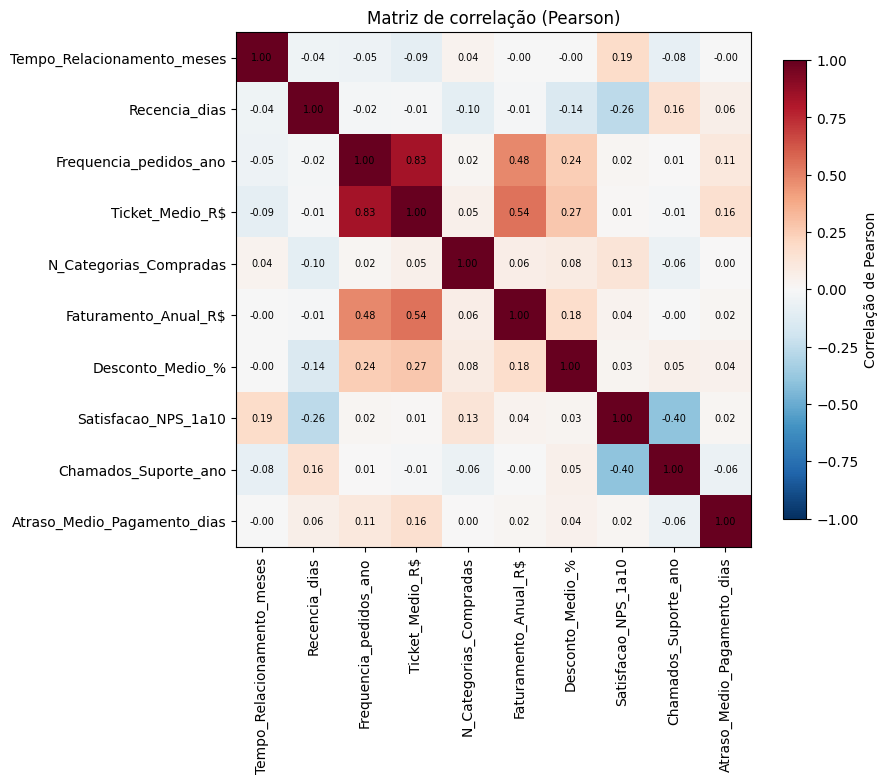

In [9]:
num_cols = df.select_dtypes(include=[np.number]).columns
# Removemos as flags binárias da matriz para focar nas variáveis contínuas/discretas
flags = [c for c in num_cols if c.startswith('Comprou_')]
num_corr = [c for c in num_cols if c not in flags]

corr = df[num_corr].corr()   # Pearson por padrão

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(num_corr)))
ax.set_yticks(range(len(num_corr)))
ax.set_xticklabels(num_corr, rotation=90)
ax.set_yticklabels(num_corr)
# Anotando cada célula com o valor
for i in range(len(num_corr)):
    for j in range(len(num_corr)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=7)
fig.colorbar(im, ax=ax, shrink=0.8, label='Correlação de Pearson')
ax.set_title('Matriz de correlação (Pearson)')
plt.tight_layout()
plt.show()

## 5. Limpeza: Valores ausentes

Dados reais têm "buracos". Precisamos detectá-los e decidir o que fazer.

In [10]:
# Quantos valores ausentes por coluna?
ausentes = df.isna().sum()
ausentes[ausentes > 0]

Desconto_Medio_%        8
Satisfacao_NPS_1a10    12
dtype: int64

### Três estratégias para valores ausentes

1. **Remover** (linhas ou colunas): simples, mas joga fora informação. Só vale
   quando há poucos ausentes ou a coluna é quase toda vazia.
2. **Imputar** (preencher): substituir pela **média**, **mediana** ou **moda**.
   - Média: boa para distribuições simétricas.
   - **Mediana**: robusta a *outliers* e a distribuições assimétricas.
   - Moda: usada em categóricos.
3. **Sinalizar com flag**: criar uma coluna `_ausente` (0/1) que marca onde havia
   buraco. O fato de estar faltando pode ser informativo (ex.: cliente que nunca
   respondeu a pesquisa de NPS).

Aqui combinamos (2) e (3): como `Desconto_Medio_%` e `Satisfacao_NPS_1a10` são
assimétricos e podem ter outliers, imputamos pela **mediana** e ainda criamos a
flag de ausência.

In [11]:
cols_ausentes = ['Desconto_Medio_%', 'Satisfacao_NPS_1a10']

for c in cols_ausentes:
    # (3) flag de ausência ANTES de preencher
    df[c + '_ausente'] = df[c].isna().astype(int)
    # (2) imputação pela mediana
    mediana_c = df[c].median()
    df[c] = df[c].fillna(mediana_c)
    print(f'{c}: imputado com mediana = {mediana_c:.2f}')

# Conferindo: não deve sobrar nenhum ausente nessas colunas
print('\nAusentes restantes nessas colunas:')
print(df[cols_ausentes].isna().sum())

Desconto_Medio_%: imputado com mediana = 8.45
Satisfacao_NPS_1a10: imputado com mediana = 7.50

Ausentes restantes nessas colunas:
Desconto_Medio_%       0
Satisfacao_NPS_1a10    0
dtype: int64


## 6. Limpeza: Outliers

*Outliers* são valores muito distantes do restante. A regra clássica é a do
**IQR (intervalo interquartil)**:

- Q1 = 1º quartil (25%), Q3 = 3º quartil (75%)
- IQR = Q3 − Q1
- Limite inferior = Q1 − 1.5 × IQR
- Limite superior = Q3 + 1.5 × IQR

Valores fora desses limites são candidatos a outlier. Uma alternativa é o
**Z-score**: considera outlier quem tem `|z| > 3`, onde `z = (x − média) / desvio`.

In [12]:
col = 'Faturamento_Anual_R$'
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1
lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

print(f'Q1 = {Q1:.2f} | Q3 = {Q3:.2f} | IQR = {IQR:.2f}')
print(f'Limite inferior = {lim_inf:.2f} | Limite superior = {lim_sup:.2f}')

outliers = df[(df[col] < lim_inf) | (df[col] > lim_sup)]
print(f'\nQtde de outliers detectados: {len(outliers)}')
print(outliers[['ID_Cliente', col]].sort_values(col, ascending=False).head())

# Para comparação, vejamos também o maior |z-score|
z = (df[col] - df[col].mean()) / df[col].std()
print(f'\nMaior |z-score| no faturamento: {z.abs().max():.2f} (regra usual: |z| > 3)')

Q1 = 1277.50 | Q3 = 9826.65 | IQR = 8549.15
Limite inferior = -11546.23 | Limite superior = 22650.38

Qtde de outliers detectados: 39
    ID_Cliente  Faturamento_Anual_R$
86     TRM1086             502693.89
46     TRM1046             106589.02
102    TRM1102              74737.36
134    TRM1134              70644.99
156    TRM1156              66297.87

Maior |z-score| no faturamento: 14.21 (regra usual: |z| > 3)


Faturamento máximo ANTES do cap : 502693.89
Faturamento máximo DEPOIS do cap: 22650.383749999997


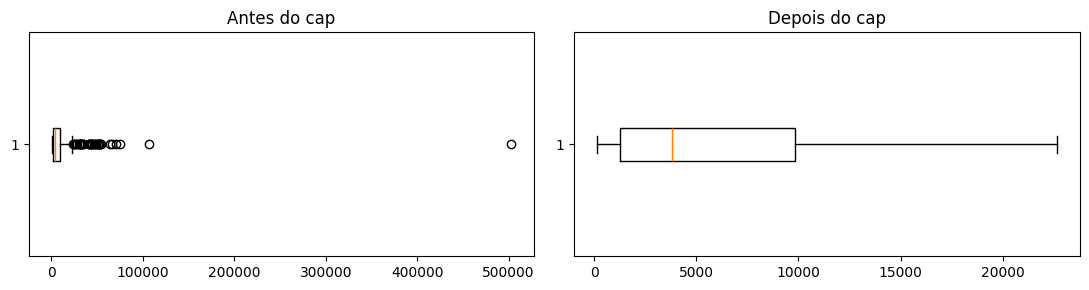

In [13]:
# Aplicando o CAP no limite superior do IQR (winsorização)
df['Faturamento_Anual_R$_original'] = df[col]   # guardamos o original para comparar
df[col] = df[col].clip(upper=lim_sup)

print('Faturamento máximo ANTES do cap :', df['Faturamento_Anual_R$_original'].max())
print('Faturamento máximo DEPOIS do cap:', df[col].max())

# Boxplot antes x depois
fig, axs = plt.subplots(1, 2, figsize=(11, 3))
axs[0].boxplot(df['Faturamento_Anual_R$_original'], vert=False)
axs[0].set_title('Antes do cap')
axs[1].boxplot(df[col], vert=False)
axs[1].set_title('Depois do cap')
plt.tight_layout()
plt.show()

## 7. Transformação: Codificação de variáveis categóricas

Modelos trabalham com números. Precisamos converter texto em valores numéricos
**preservando o significado**.

- **Ordinal** (`Porte_Cliente`): existe ordem natural, então mapeamos para
  inteiros que **respeitam essa ordem**: Pequeno=1, Médio=2, Grande=3.
- **Nominal** (`Regiao`, `Canal_Venda`, `Segmento`): não há ordem. Usamos
  **one-hot encoding** (codificação *1-de-k*): cada categoria vira uma coluna 0/1.
  Assim não inventamos uma ordem que não existe.
- **Alvo** (`Churn`): mapeamos Não=0, Sim=1.

In [14]:
# Ordinal: preserva a ordem Pequeno < Médio < Grande
ordem_porte = {'Pequeno': 1, 'Médio': 2, 'Grande': 3}
df['Porte_Cliente_ord'] = df['Porte_Cliente'].map(ordem_porte)

# Alvo: Não -> 0, Sim -> 1
df['Churn_bin'] = df['Churn'].map({'Não': 0, 'Sim': 1})

print(df[['Porte_Cliente', 'Porte_Cliente_ord', 'Churn', 'Churn_bin']].head())

  Porte_Cliente  Porte_Cliente_ord Churn  Churn_bin
0        Grande                  3   Sim          1
1       Pequeno                  1   Sim          1
2       Pequeno                  1   Não          0
3         Médio                  2   Sim          1
4       Pequeno                  1   Sim          1


In [15]:
# Nominal: one-hot encoding (1-de-k)
nominais = ['Regiao', 'Canal_Venda', 'Segmento']
dummies = pd.get_dummies(df[nominais], prefix=nominais).astype(int)
print('Novas colunas one-hot:', list(dummies.columns))

df = pd.concat([df, dummies], axis=1)
dummies.head()

Novas colunas one-hot: ['Regiao_Centro-Oeste', 'Regiao_Nordeste', 'Regiao_Norte', 'Regiao_Sudeste', 'Regiao_Sul', 'Canal_Venda_Atacado', 'Canal_Venda_Distribuidor', 'Canal_Venda_E-commerce', 'Canal_Venda_Marketplace', 'Canal_Venda_Varejo Físico', 'Segmento_Corporativo', 'Segmento_Doméstico', 'Segmento_Profissional/Food Service']


,Regiao_Centro-Oeste,Regiao_Nordeste,Regiao_Norte,Regiao_Sudeste,Regiao_Sul,Canal_Venda_Atacado,Canal_Venda_Distribuidor,Canal_Venda_E-commerce,Canal_Venda_Marketplace,Canal_Venda_Varejo Físico,Segmento_Corporativo,Segmento_Doméstico,Segmento_Profissional/Food Service
0,0,1,0,0,0,0,0,0,0,1,0,1,0
1,0,0,0,1,0,0,0,0,1,0,1,0,0
2,0,0,1,0,0,0,0,1,0,0,0,1,0
3,0,1,0,0,0,0,0,0,0,1,0,0,1
4,0,0,0,0,1,1,0,0,0,0,1,0,0


## 8. Feature engineering: criando novos atributos

Boas *features* **deixam o padrão explícito** para o modelo. Em vez de esperar
que o algoritmo "descubra" relações, nós as construímos a partir do conhecimento
de negócio. Vamos criar três:

1. **`Faturamento_por_Pedido`** = Faturamento Anual / Frequência de pedidos,
   quanto o cliente gera por pedido (com proteção contra divisão por zero).
2. **`Total_Categorias_Compradas`** = soma das flags `Comprou_*`, amplitude do
   relacionamento (quantas linhas de produto o cliente compra).
3. **`Cliente_Insatisfeito`** = 1 se NPS ≤ 6 (detratores), senão 0, sinal de
   risco de churn explícito.

In [16]:
# 1. Faturamento por pedido (guarda contra divisão por zero)
freq = df['Frequencia_pedidos_ano'].replace(0, np.nan)
df['Faturamento_por_Pedido'] = (df['Faturamento_Anual_R$'] / freq).fillna(0)

# 2. Total de categorias compradas = soma das flags Comprou_*
flags_compra = [c for c in df.columns if c.startswith('Comprou_')]
df['Total_Categorias_Compradas'] = df[flags_compra].sum(axis=1)

# 3. Cliente insatisfeito (detrator de NPS)
df['Cliente_Insatisfeito'] = (df['Satisfacao_NPS_1a10'] <= 6).astype(int)

In [17]:
df[['ID_Cliente', 'Faturamento_por_Pedido',
    'Total_Categorias_Compradas', 'Cliente_Insatisfeito']].head()

,ID_Cliente,Faturamento_por_Pedido,Total_Categorias_Compradas,Cliente_Insatisfeito
0,TRM1000,707.824492,2,0
1,TRM1001,377.032500,7,0
2,TRM1002,182.794286,3,0
3,TRM1003,504.125000,3,0
4,TRM1004,274.298750,6,0


## 9. Transformação: Normalização e padronização

Variáveis em escalas diferentes podem distorcer modelos baseados em **distância**
(como o k-NN e o k-Means). Exemplo clássico: comparar *idade* (0 a 100) com
*salário* (milhares de reais), o salário domina o cálculo de distância só por
ter números maiores. A solução é colocar tudo na mesma escala.

Duas abordagens:

- **Normalização Min-Max**: `(x − min) / (max − min)` → resultado entre 0 e 1.
  Boa quando queremos um intervalo fixo; sensível a outliers.
- **Padronização Z-score**: `(x − média) / desvio` → média 0 e desvio 1.
  Mais robusta e a mais usada como padrão.

Como o *feature engineering* já foi executado, os novos atributos numéricos
entram no mesmo processo de padronização.

In [18]:
# Colunas numéricas que fazem sentido escalar (excluímos flags, alvo e auxiliares)
colunas_escalar = [
    'Tempo_Relacionamento_meses', 'Recencia_dias', 'Frequencia_pedidos_ano',
    'Ticket_Medio_R$', 'N_Categorias_Compradas', 'Faturamento_Anual_R$',
    'Desconto_Medio_%', 'Satisfacao_NPS_1a10', 'Chamados_Suporte_ano',
    'Atraso_Medio_Pagamento_dias', 'Porte_Cliente_ord',
    'Faturamento_por_Pedido', 'Total_Categorias_Compradas'
]

# Demonstração das duas técnicas no Ticket_Medio_R$
demo = df['Ticket_Medio_R$']
minmax_demo = (demo - demo.min()) / (demo.max() - demo.min())
zscore_demo = (demo - demo.mean()) / demo.std()

comparacao = pd.DataFrame({
    'original': demo,
    'min_max [0,1]': minmax_demo,
    'z_score (μ=0,σ=1)': zscore_demo
})
print(comparacao.describe().round(3))

# Aplicando a PADRONIZAÇÃO (z-score) e guardando em novas colunas *_z
for c in colunas_escalar:
    df[c + '_z'] = (df[c] - df[c].mean()) / df[c].std()

# Conferindo: as colunas padronizadas devem ter média ~0 e desvio ~1
cols_z = [c + '_z' for c in colunas_escalar]
df[cols_z].describe().loc[['mean', 'std']].round(3)

       original  min_max [0,1]  z_score (μ=0,σ=1)
count   260.000        260.000            260.000
mean    438.699          0.203              0.000
std     340.817          0.214              1.000
min     115.940          0.000             -0.947
25%     193.395          0.049             -0.720
50%     292.980          0.111             -0.428
75%     554.390          0.276              0.339
max    1706.550          1.000              3.720


,Tempo_Relacionamento_meses_z,Recencia_dias_z,Frequencia_pedidos_ano_z,Ticket_Medio_R$_z,N_Categorias_Compradas_z,Faturamento_Anual_R$_z,Desconto_Medio_%_z,Satisfacao_NPS_1a10_z,Chamados_Suporte_ano_z,Atraso_Medio_Pagamento_dias_z,Porte_Cliente_ord_z,Faturamento_por_Pedido_z,Total_Categorias_Compradas_z
mean,0.0,0.0,-0.0,0.0,0.0,0.0,-0.0,-0.0,-0.0,0.0,0.0,-0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


## 10. Resultado final e exportação

Chegamos ao fim do *pipeline* de preparação. O *dataframe* agora contém:
os atributos originais limpos, as colunas imputadas + flags de ausência,
o faturamento "capado", as codificações ordinal/one-hot/alvo, as versões
padronizadas (`*_z`) e os novos atributos de *feature engineering*.

In [19]:
print('Dimensões do dataset processado:', df.shape)
df.head()

Dimensões do dataset processado: (260, 58)


,ID_Cliente,Regiao,Canal_Venda,Porte_Cliente,Segmento,Tempo_Relacionamento_meses,Recencia_dias,Frequencia_pedidos_ano,Ticket_Medio_R$,N_Categorias_Compradas,...,Ticket_Medio_R$_z,N_Categorias_Compradas_z,Faturamento_Anual_R$_z,Desconto_Medio_%_z,Satisfacao_NPS_1a10_z,Chamados_Suporte_ano_z,Atraso_Medio_Pagamento_dias_z,Porte_Cliente_ord_z,Faturamento_por_Pedido_z,Total_Categorias_Compradas_z
0,TRM1000,Nordeste,Varejo Físico,Grande,Doméstico,39,46,32,760.32,2,...,0.943675,-1.631688,2.014396,-1.816156,-0.067118,0.661250,-0.448760,1.819176,0.696672,-1.631688
1,TRM1001,Sudeste,Marketplace,Pequeno,Corporativo,25,45,8,259.22,7,...,-0.526613,1.817408,-0.545832,0.334184,0.082034,0.661250,0.042170,-0.868243,-0.293964,1.817408
2,TRM1002,Norte,E-commerce,Pequeno,Doméstico,40,12,7,191.00,3,...,-0.726779,-0.941869,-0.772293,-0.079343,0.604066,-0.775449,-0.612403,-0.868243,-0.875656,-0.941869
3,TRM1003,Nordeste,Varejo Físico,Médio,Profissional/Food Service,69,208,14,511.54,3,...,0.213724,-0.941869,-0.018835,-1.532595,0.007458,-0.296549,2.169530,0.475466,0.086645,-0.941869
4,TRM1004,Sul,Atacado,Pequeno,Corporativo,9,48,8,224.20,6,...,-0.629366,1.127589,-0.653002,-0.374719,0.082034,2.097949,-0.939689,-0.868243,-0.601624,1.127589


In [20]:
# Salvando o resultado. No Colab, baixe pelo painel de arquivos
# (clique nos três pontos ao lado do arquivo -> Download).
SAIDA = 'tramontina_clientes_processado.csv'
df.to_csv(SAIDA, index=False)
print('Arquivo salvo em:', SAIDA)

Arquivo salvo em: tramontina_clientes_processado.csv
